## This analysis aims to understand customer behavior in order to implement personalized marketing.

In [1]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine
import pandas as pd

In [2]:
load_dotenv()
user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT")
database = os.getenv("DB_NAME")

try:
    folder = r"C:\Professional_project\Churn_and_Marketing_Analytics\Script_SQL"
    file = "classification_dataset.sql"
    path = os.path.join(folder, file)

    with open(path, 'r', encoding='utf-8') as f:
        sql = f.read()

    engine = create_engine(f'postgresql+psycopg2://{user}:{password}@{host}:{port}/{database}',
    connect_args={"sslmode": "require"})

    dataset = pd.read_sql(sql, con=engine)
    print("The data has been successfully loaded!!!")

except FileNotFoundError:
    print(f"The file was not found in the path:{path}")

except Exception as e:
    print(f'--Error details--: {e}')

finally:
    engine.dispose()

The data has been successfully loaded!!!


In [3]:
features = dataset.drop(["customer_unique_id", "customer_state", "total_price", 
"total_freight", "last_purchase", "first_purchase"], axis=1)

In [5]:
features.isnull().sum()

total_paid_items          0
payment_installments      1
total_orders              0
customer_lifetime_days    0
avg_order_value           0
recency_days              0
dtype: int64

In [6]:
features[features["payment_installments"].isna()]

,total_paid_items,payment_installments,total_orders,customer_lifetime_days,avg_order_value,recency_days
48988,143.46,NaN,1,0,143.46,718


In [8]:
features = features.dropna()

,total_paid_items,payment_installments,total_orders,customer_lifetime_days,avg_order_value,recency_days
0,141.90,8.0,1,0,141.90,116
1,27.19,1.0,1,0,27.19,119
2,86.22,8.0,1,0,86.22,542
3,43.62,4.0,1,0,43.62,326
4,196.89,6.0,1,0,196.89,293
...,...,...,...,...,...,...
95453,2067.42,10.0,1,0,2067.42,452
95454,84.58,1.0,1,0,84.58,267
95455,112.46,1.0,1,0,112.46,573
95456,133.69,5.0,1,0,133.69,124


### Exploratory data analysis

In [14]:
features.describe()

,total_paid_items,payment_installments,total_orders,customer_lifetime_days,avg_order_value,recency_days
count,95457.000000,95457.000000,95457.000000,95457.000000,95457.000000,95457.000000
mean,173.549806,2.903700,1.033607,2.625412,168.366932,243.539133
std,262.999658,2.678649,0.210014,24.899309,255.575222,153.169117
min,10.070000,0.000000,1.000000,0.000000,10.070000,0.000000
25%,64.000000,1.000000,1.000000,0.000000,63.270000,119.000000
50%,110.630000,2.000000,1.000000,0.000000,107.850000,224.000000
75%,188.360000,4.000000,1.000000,0.000000,182.550000,353.000000
max,13664.080000,24.000000,16.000000,633.000000,13664.080000,729.000000


*Exploratory analysis reveals low purchase frequency. Over 75% of customers made only one purchase, which is reflected in both the distribution of total orders and customer lifetime (days), where the majority of customers have an activity duration of zero days. This suggests that the platform faces retention challenges and that segmentation could help identify profiles with greater loyalty potential.*

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

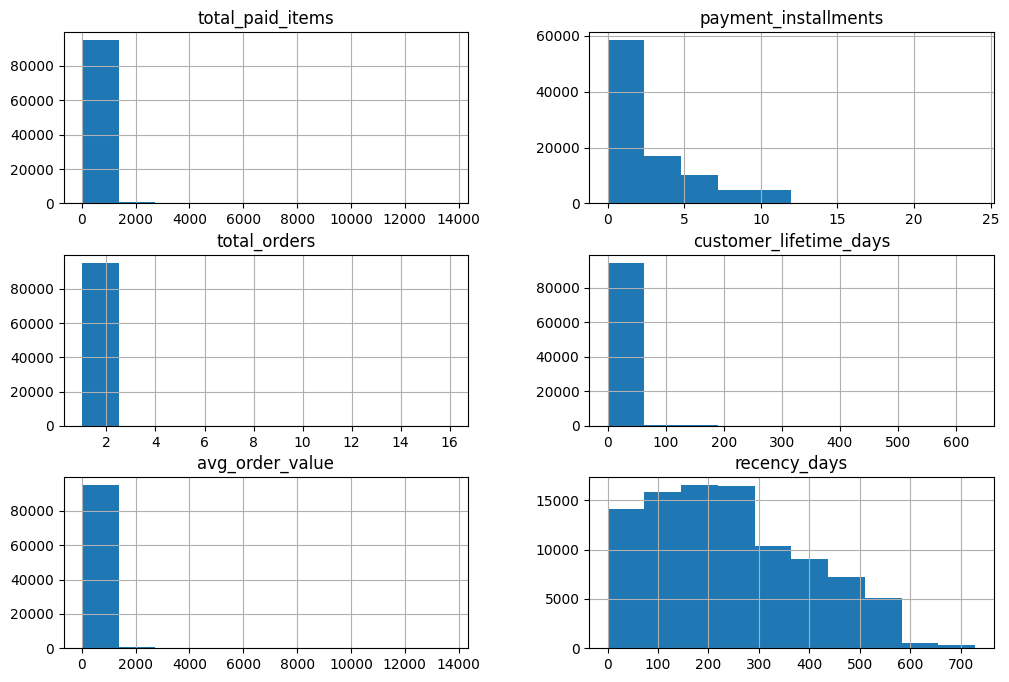

In [15]:
features.hist(figsize=(12,8))
plt.show()

*La variable Recency muestra una dispersión considerable. Existen clientes cuya última compra ocurrió cerca del final del período analizado y otros que dejaron de comprar varios cientos de días antes, lo que sugiere distintos niveles de actividad y posible abandono.*

<Axes: >

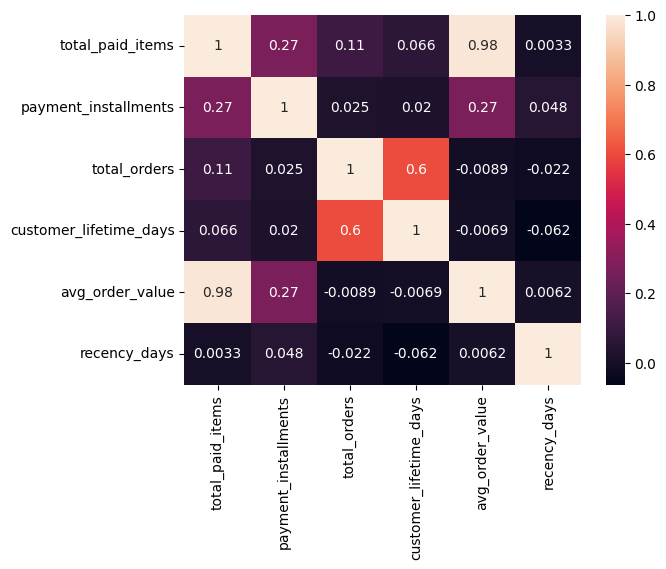

In [20]:
sns.heatmap(features.corr(), annot=True)

<Axes: xlabel='total_orders', ylabel='total_paid_items'>

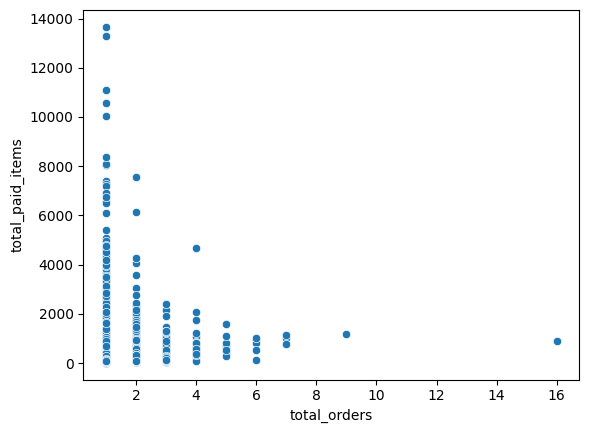

In [21]:
sns.scatterplot(data=features, x="total_orders", y="total_paid_items")

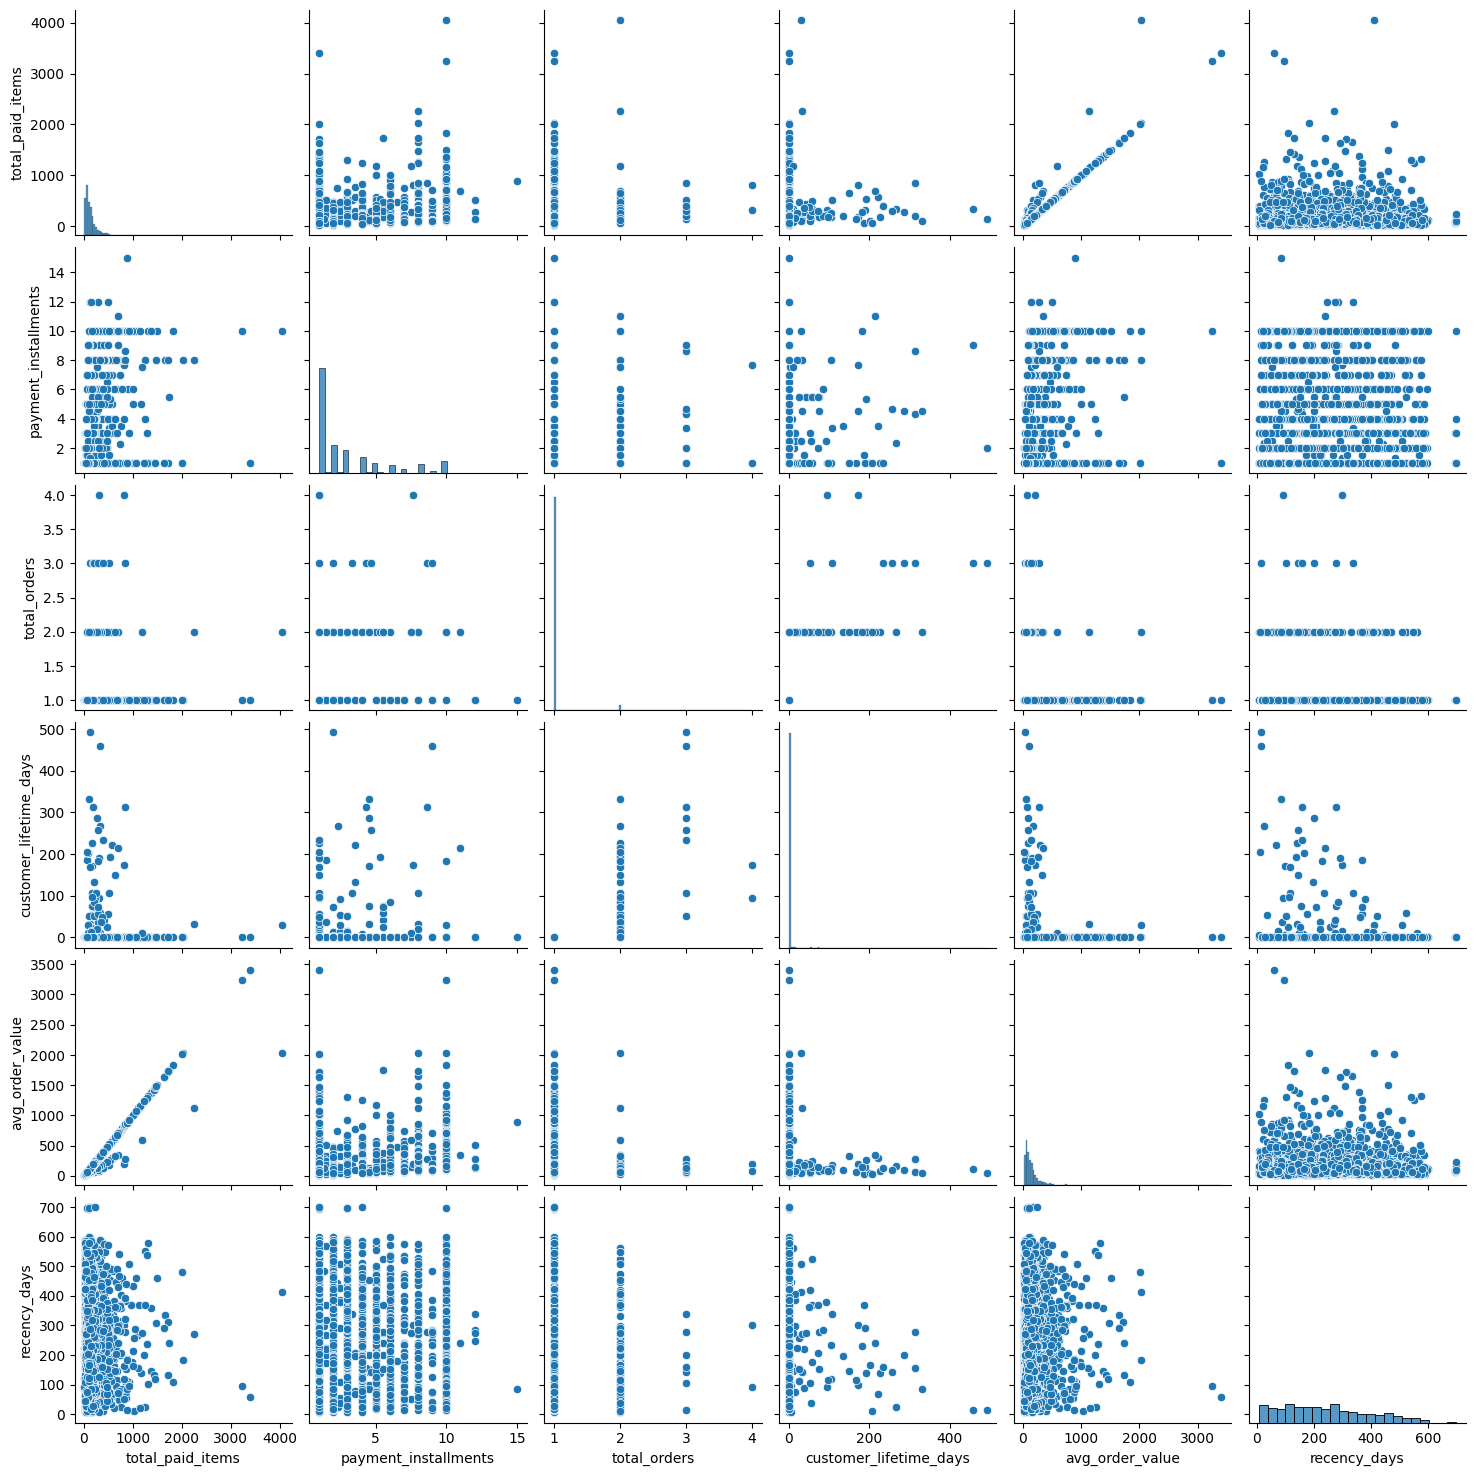

In [22]:
sns.pairplot(
    features.sample(3000))

### Variable selection and outlier handling

In [23]:
ml_df = features.drop("avg_order_value", axis=1)

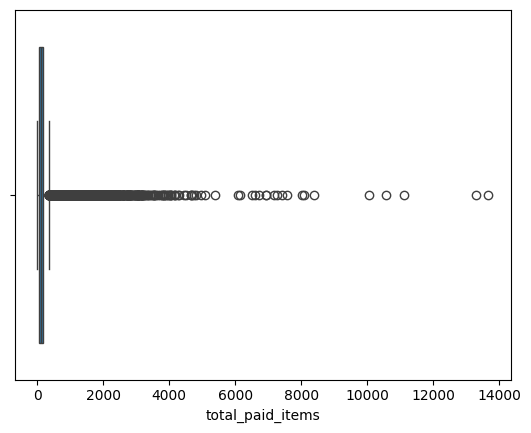

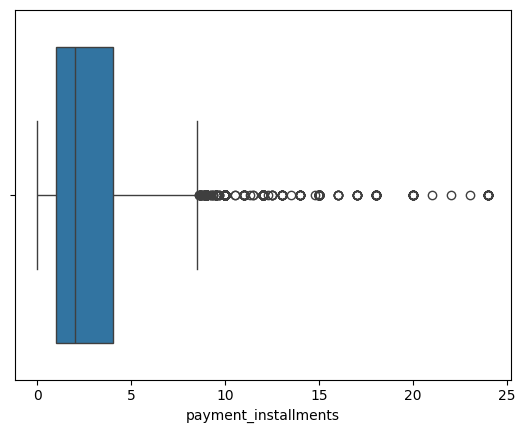

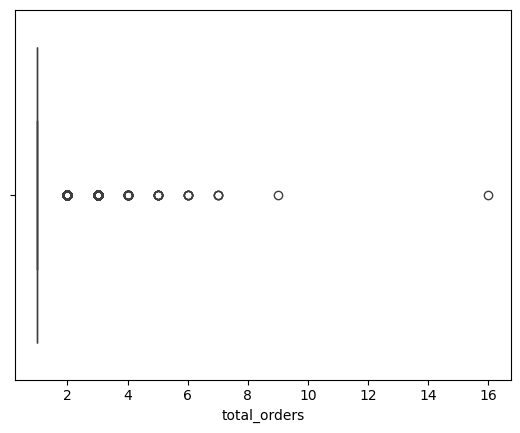

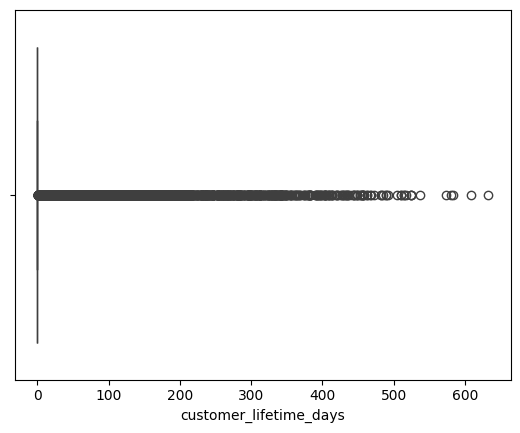

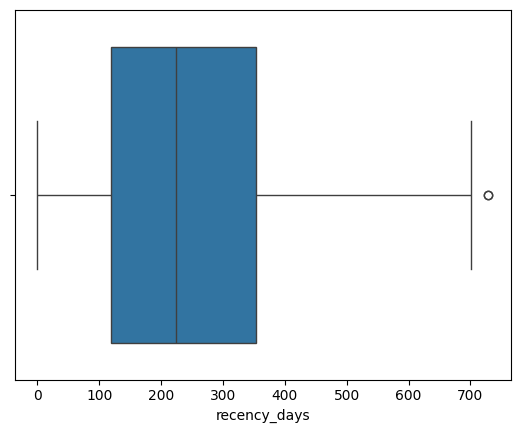

In [25]:
for col in ml_df.columns:
    sns.boxplot(x=ml_df[col])
    plt.show()

### Log Transform and standardisation

In [26]:
import numpy as np

In [27]:
ml_df["total_paid_items"] = np.log1p(ml_df["total_paid_items"])

ml_df["customer_lifetime_days"] = np.log1p(ml_df["customer_lifetime_days"])

*Due to the strong positive skewness observed in total_paid_items and customer_lifetime_days, a logarithmic transformation (log1p) was applied. This transformation reduces the influence of extreme values while preserving the relative differences between customers, improving the performance of distance-based clustering algorithms such as K-Means.*

<Axes: xlabel='total_paid_items'>

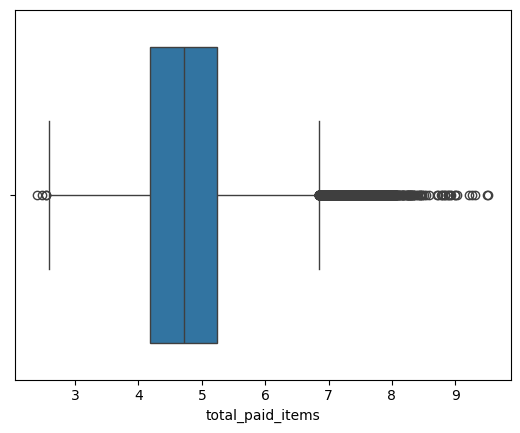

In [30]:
sns.boxplot(x=ml_df["total_paid_items"])


<Axes: xlabel='customer_lifetime_days'>

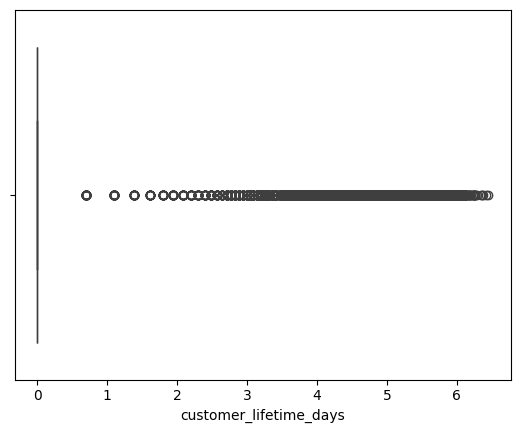

In [32]:
sns.boxplot(x=ml_df["customer_lifetime_days"])

Text(0.5, 1.0, 'Log1p')

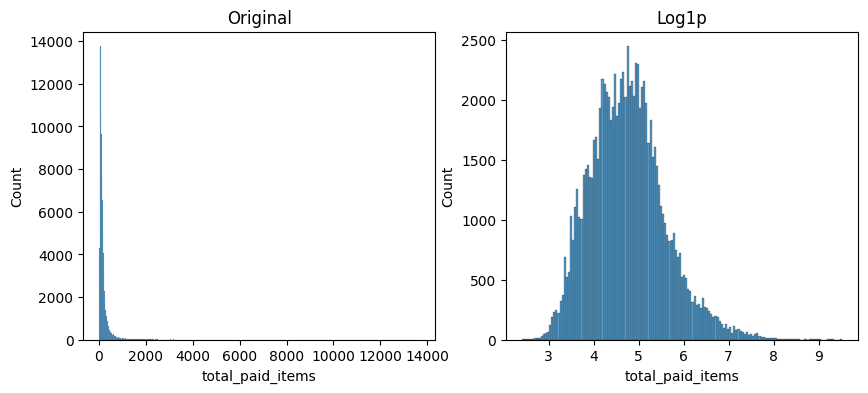

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

sns.histplot(dataset["total_paid_items"], ax=ax[0])
ax[0].set_title("Original")

sns.histplot(ml_df["total_paid_items"], ax=ax[1])
ax[1].set_title("Log1p")

In [33]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(ml_df)

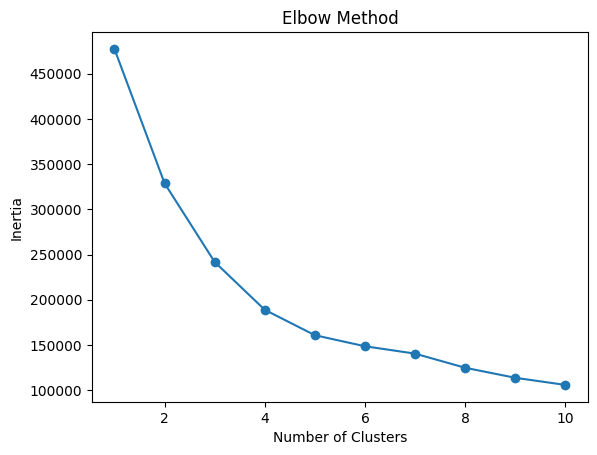

In [39]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    
    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

info()
describe()
Histograms
Boxplots
Correlation Heatmap
Pairplot
Tratamiento de outliers
Log Transformation (si es necesaria)
StandardScaler
K-Means


​